## Map-to-Prediciton 

This book takes in a calibrated water elevation map for a specific site and a set of test images and predicits the water in each image in (ft). 

In [1]:
import os
import glob
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
from PIL import Image
import cv2
import torch
import json


## Existing Sites

Runs with an existing `run_config.json`:

In [2]:
site_list = sorted(glob.glob('cameras/*/*/run_config.json'))
for i, cfg in enumerate(site_list):
    parts = cfg.split(os.sep)
    print(f"Site {i} = '{parts[1]}'")
    print()

Site 0 = 'CA_Arroyo_DE_LA_Laguna_A_Corte_Madrid_nr_Pleasanton'

Site 1 = 'OK_Illinois_River_near_Moodys'

Site 2 = 'SC_Waccamaw_River_at_SC_22_below_Longs'

Site 3 = 'VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX'

Site 4 = 'WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet'

Site 5 = 'WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet'



## Configuration

In [3]:
# Select site and test dierctory. The test data will be drawn from the specified folder for the camera

##### Input ####
site_selection = 4
test_run_name = 'test_2025-03-25'

################

cfg_path = site_list[site_selection]

if os.path.exists(cfg_path):
    with open(cfg_path) as f:
        cfg = json.load(f)

camera_id = cfg.get('camera_id')
run_name  = cfg.get('run_name')
run_dir = f'cameras/{camera_id}/{run_name}'

evel_path = f'{run_dir}/depth/calibrated_elevation.npy'

print(f'Using elevation map from: {evel_path}')

test_dir = f'cameras/{camera_id}/{test_run_name}'

images_dir = f'{test_dir}/images'
masks_dir = f'{test_dir}/masks'
csv_path = f'{test_dir}/images_and_data.csv'

# Output directory
output_dir = f'{test_dir}/predicitons'
os.makedirs(output_dir, exist_ok=True)

print(f"Loading data from: {csv_path}")
print(f"Output will be saved to: {output_dir}")

Using elevation map from: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/event_2025-06-23/depth/calibrated_elevation.npy
Loading data from: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/test_2025-03-25/images_and_data.csv
Output will be saved to: cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/test_2025-03-25/predicitons


## Load Elevation Map and Data


No quality_flag column found - using all masks
(Run notebook 02.5 to review and flag bad masks)
Loaded 114 records

Columns: ['Unnamed: 0', 'image_times', 'image_names', 'data_times', 'site_no', '00060', '00060_cd', '00065', '00065_cd', '63160', '63160_cd', 'time_diff_sec', 'mask_filename']

First few rows:


,image_names,mask_filename
0,WI_East_Branch_Pecatonica_River_near_Blanchard...,00000_obj1.npy
1,WI_East_Branch_Pecatonica_River_near_Blanchard...,00001_obj1.npy
2,WI_East_Branch_Pecatonica_River_near_Blanchard...,00002_obj1.npy
3,WI_East_Branch_Pecatonica_River_near_Blanchard...,00003_obj1.npy
4,WI_East_Branch_Pecatonica_River_near_Blanchard...,00004_obj1.npy


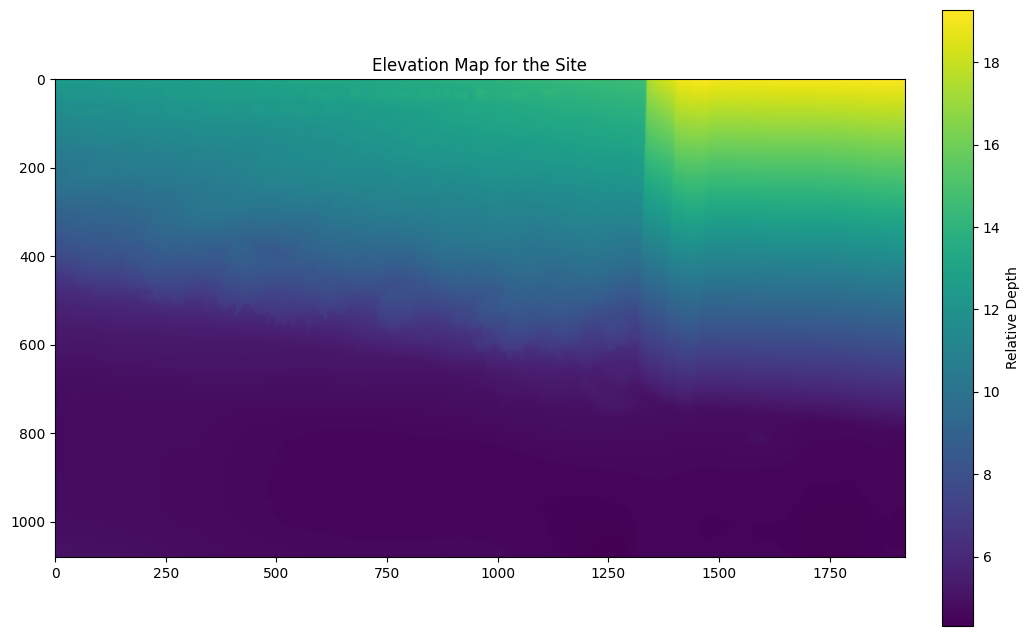

In [4]:
elevation_map = np.load(evel_path)
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(elevation_map)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Relative Depth')
plt.title("Elevation Map for the Site")

# Load the CSV with images, masks, and gage height data
df = pd.read_csv(csv_path)

# Filter out bad quality masks if quality_flag column exists
if 'quality_flag' in df.columns:
    n_bad = (df['quality_flag'] == 'bad').sum()
    if n_bad > 0:
        print(f"\nFound {n_bad} masks marked as 'bad' - excluding from analysis")
        bad_indices = df[df['quality_flag'] == 'bad'].index.tolist()
        print(f"Excluded indices: {bad_indices}")
        df = df[df['quality_flag'] != 'bad'].reset_index(drop=True)
        print(f"Remaining records after filtering: {len(df)}")
    else:
        print(f"\nAll masks marked as 'good' - no filtering applied")
else:
    print(f"\nNo quality_flag column found - using all masks")
    print(f"(Run notebook 02.5 to review and flag bad masks)")


print(f"Loaded {len(df)} records")

print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
display(df[['image_names', 'mask_filename']].head())


In [5]:
def load_mask(mask_path):
    """
    Load a mask from a .npy file.
    
    Args:
        mask_path: Path to .npy mask file
    
    Returns:
        Binary mask array
    """
    mask = np.load(mask_path)
    if mask.ndim == 3:
        mask = mask.squeeze()
    return mask.astype(bool)



In [53]:
def predict_elevation(elevation_map, water_mask, return_vals = False):
    """
    Predicts the water eleveation from an image and elevation map using median 
    
    Args:
        elevation_map: Map of water elevations for the site
        water_mask: Mask of the water 
    
    Returns:
        predicted_elevation: Predicted water elevation
    """
    # Find edge by subtarcting the erroded image
    kernel = np.ones((3,3), np.uint8)
    erosion = cv2.erode(water_mask.astype(np.uint8), kernel, iterations=1)
    edges = cv2.subtract(water_mask.astype(np.uint8), erosion)
    edges = cv2.dilate(edges.astype(np.uint8), kernel, iterations=1)

    edges = edges.astype(bool)
    elevation_vals = elevation_map[edges]

    predicted_elevation = np.median(elevation_vals)

    if return_vals == True:
        return predicted_elevation, elevation_vals

    return predicted_elevation

    # print(f"Predicted Elevation: {predicted_elevation}")
    # plt.figure()
    # plt.imshow(edges.astype(bool))
    # plt.figure()
    # plt.hist(elevation_vals)

MAE: 0.1240850172961111 ft
cameras/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet/test_2025-03-25/images/WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet___2025-04-03T12-00-03Z.jpg
Test Data Range: 4.81-7.03ft.
Map Range: 4.325735072580255-19.261543782686857ft.
Worst Case Prediciton: 7.374902422821625, True: 7.03


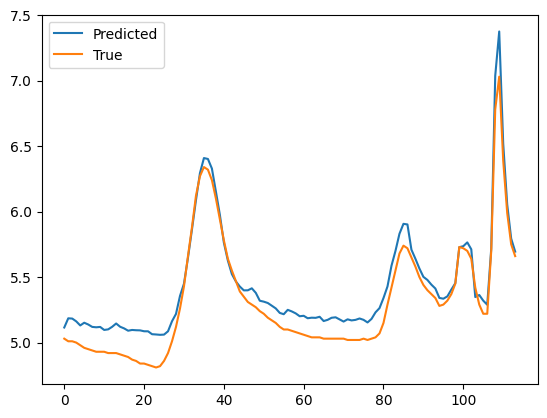

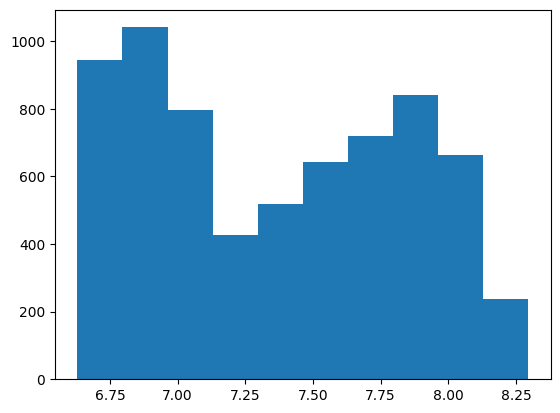

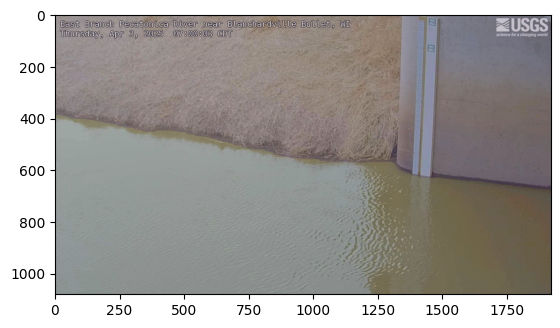

In [55]:
predicted_water_evevations = []
for idx, row in df.iterrows():
    mask_path = os.path.join(masks_dir, row['mask_filename'])
    if not os.path.exists(mask_path):
        print(f"Warning: Mask not found: {mask_path}")
        continue

    mask = load_mask(mask_path)
    pred = predict_elevation(elevation_map, mask)
    predicted_water_evevations.append(pred)

predicted_water_elevations = np.array(predicted_water_evevations)
true_water_elevations = df['00065']

plt.figure()
plt.plot(predicted_water_elevations)
plt.plot(true_water_elevations)
plt.legend(("Predicted", "True"))

errors = (np.abs(predicted_water_elevations-true_water_elevations))
mae = np.mean(errors)
print(f"MAE: {mae} ft")

worst_error = np.argmax(errors)
worst_frame = df.iloc[worst_error]
worst_image_path = os.path.join(images_dir, worst_frame['image_names'])
worst_mask_path = os.path.join(masks_dir, worst_frame['mask_filename'])

worst_mask = load_mask(worst_mask_path)
predicted, pred_vals = predict_elevation(elevation_map, worst_mask, True)

plt.figure()
plt.hist(pred_vals)

print(worst_image_path)
worst_image = cv2.cvtColor(cv2.imread(worst_image_path), code=cv2.COLOR_BGR2RGB)

print(f"Test Data Range: {np.min(true_water_elevations)}-{np.max(true_water_elevations)}ft.")
print(f"Map Range: {np.min(elevation_map)}-{np.max(elevation_map)}ft.")
print(f"Worst Case Prediciton: {predicted_water_elevations[worst_error]}, True: {true_water_elevations[worst_error]}")

plt.figure()
plt.imshow(worst_image)
plt.imshow(worst_mask, alpha=0.1)
